# 📊 Financial Data Processing & Graph Engineering Pipeline
## Nền tảng Tiền xử lý, Trích xuất Đặc trưng & Khởi tạo Đồ thị Tương tác Tài chính

Dự án **RinRec** - Hệ thống Gợi ý Cá nhân hóa Sản phẩm Tài chính & Dịch vụ Quầy Ngân hàng.

Notebook này triển khai toàn bộ pipeline dữ liệu từ nguồn CSDL Master Data (`E:\Fintech\Fintech`), bao gồm:
1. **Khởi tạo & Nạp CSDL Ngân hàng**: Hồ sơ khách hàng (`dim_customer`), Lịch sử giao dịch (`fact_transaction`), Sản phẩm đang sở hữu (`fact_customer_product`), Danh mục 78 dịch vụ quầy (`01_danh_muc_dich_vu.csv`) và 26 sản phẩm tài chính (`03_danh_muc_san_pham.csv`).
2. **Làm sạch & Chuẩn hóa Dữ liệu (Data Cleaning)**: Xử lý định dạng tiền tệ, ngày tháng, loại bỏ bản ghi thiếu, chuẩn hóa phân khúc `MASS`, `PRIME`, `DIAMOND`.
3. **Phân tích Khám phá Dữ liệu (EDA)**: Phân phối dòng tiền, ma trận tương quan danh mục chéo, tần suất giao dịch theo kênh (Counter, App, ATM).
4. **Feature Engineering & Trọng số Tương tác RFM**: Tính toán điểm số tương tác phản ánh độ gắn kết và tính cập nhật theo thời gian (Recency Decay).
5. **Xây dựng Đồ thị Bipartite Graph**: Tính toán bậc node và trọng số chuẩn hóa $\beta_{ui} = \frac{1}{\sqrt{\deg(u) \cdot \deg(i)}}$ phục vụ huấn luyện **UltraGCN**.

### 1. Cài đặt & Nạp các Thư viện Khoa học Dữ liệu

In [14]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('✅ Đã nạp thành công các thư viện phân tích dữ liệu!')

✅ Đã nạp thành công các thư viện phân tích dữ liệu!


### 2. Nạp Dữ liệu Master Data & Dữ liệu Giao dịch Ngân hàng

In [15]:
import sys
from pathlib import Path

core_dir = Path(r"E:\RinRec_Demo\core")
if str(core_dir) not in sys.path:
    sys.path.insert(0, str(core_dir))

from mongo_connector import get_collection_df, save_df_to_collection

print('📡 Đang kết nối và tải dữ liệu từ MongoDB Atlas (RinRec_DB)...')
df_customers = get_collection_df('dim_customer')
df_products = get_collection_df('DanhMucSanPham')
df_services = get_collection_df('DanhMucDichVu')
df_transactions = get_collection_df('factTransaction')

df_holdings = get_collection_df('factCustomerProduct')
df_rules = get_collection_df('RuleGoiY')

if df_customers.empty or df_transactions.empty:
    raise RuntimeError('❌ Không thể nạp dữ liệu từ MongoDB Atlas! Vui lòng kiểm tra kết nối mạng trong mongo_connector.py.')

print(f'📊 Dữ liệu: {len(df_customers)} Khách hàng | {len(df_products)} Sản phẩm | {len(df_services)} Dịch vụ quầy | {len(df_transactions)} Giao dịch')


📡 Đang kết nối và tải dữ liệu từ MongoDB Atlas (RinRec_DB)...
📊 Dữ liệu: 120 Khách hàng | 11 Sản phẩm | 78 Dịch vụ quầy | 3001 Giao dịch


### 3. Phân tích Khám phá Dữ liệu (EDA)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3436\809467657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_customers, x='segment', palette='Blues_r', ax=axes[0])


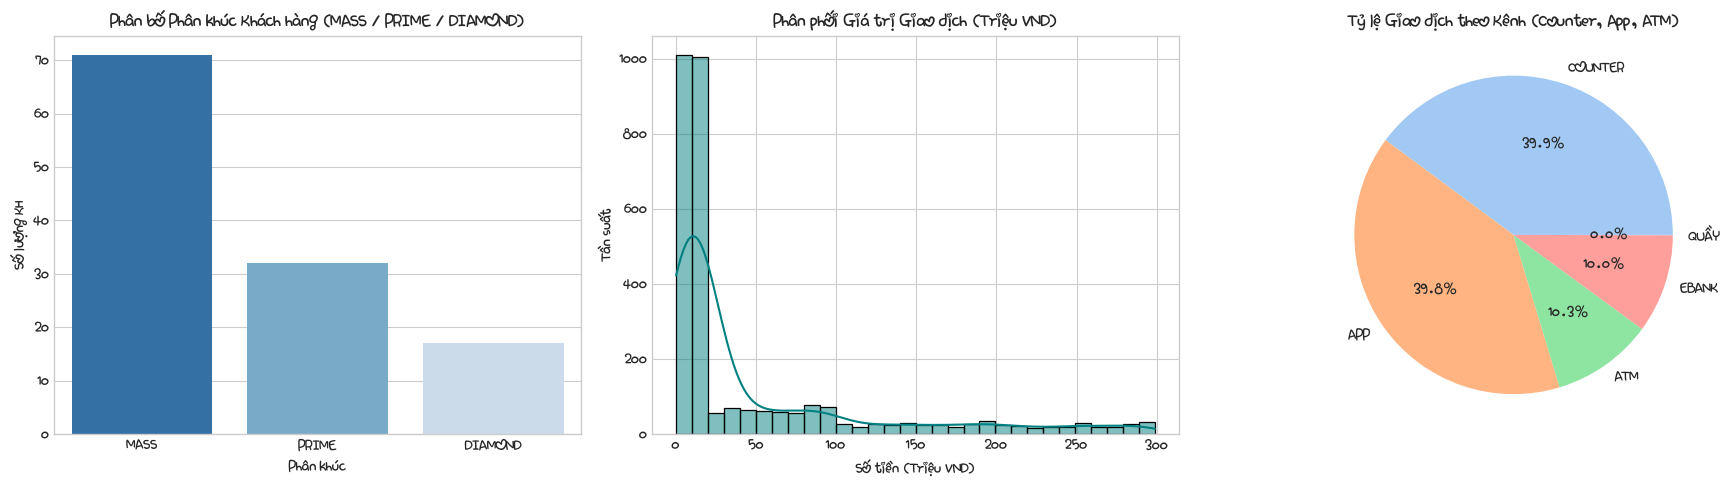

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Phân bố phân khúc khách hàng
sns.countplot(data=df_customers, x='segment', palette='Blues_r', ax=axes[0])
axes[0].set_title('Phân bố Phân khúc Khách hàng (MASS / PRIME / DIAMOND)')
axes[0].set_xlabel('Phân khúc')
axes[0].set_ylabel('Số lượng KH')

# Biểu đồ 2: Phân bố số tiền giao dịch
sns.histplot(df_transactions['amount'] / 1e6, bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Phân phối Giá trị Giao dịch (Triệu VND)')
axes[1].set_xlabel('Số tiền (Triệu VND)')
axes[1].set_ylabel('Tần suất')

# Biểu đồ 3: Tỷ lệ giao dịch theo kênh
df_transactions['channel'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), ax=axes[2])
axes[2].set_title('Tỷ lệ Giao dịch theo Kênh (Counter, App, ATM)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### 4. Feature Engineering & Tính toán Trọng số Tương tác RFM

In [17]:
service_to_prod = {
    'A. Tài khoản & Thông tin KH': 'SP024',
    'B. Giao dịch tiền mặt': 'SP004',
    'C. Tiết kiệm & Tiền gửi': 'SP001',
    'D. Thẻ': 'SP004',
    'E. Chuyển tiền & Thanh toán': 'SP021',
    'F. Ngoại tệ': 'SP018',
    'G. Tín dụng': 'SP008',
    'H. Bảo hiểm & Đầu tư': 'SP013',
    'I. Ngân hàng số & Hỗ trợ': 'SP021',
    'J. Khách hàng doanh nghiệp': 'SP025'
}

interactions = []
for _, row in df_holdings.iterrows():
    c_id = int(row['customer_id'])
    p_id = str(row['product_id'])
    bal = float(row.get('current_balance', 10_000_000))
    rating = 4.5 + min(0.5, np.log10(max(1, bal)) / 10.0)
    interactions.append({'customer_id': c_id, 'product_id': p_id, 'rating': rating, 'amount': bal})

for _, row in df_transactions.iterrows():
    c_id = int(row['customer_id'])
    s_grp = str(row['service_group'])
    p_id = service_to_prod.get(s_grp, 'SP001')
    amt = float(row.get('amount', 1_000_000))
    rating = min(4.5, 1.0 + (np.log1p(amt) / 18.0) * 3.5)
    interactions.append({'customer_id': c_id, 'product_id': p_id, 'rating': rating, 'amount': amt})

df_inter = pd.DataFrame(interactions)
df_grouped = df_inter.groupby(['customer_id', 'product_id']).agg({'rating': 'mean', 'amount': 'sum'}).reset_index()

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
df_grouped['user_idx'] = user_encoder.fit_transform(df_grouped['customer_id'])
df_grouped['item_idx'] = item_encoder.fit_transform(df_grouped['product_id'])

print(f'✅ Ma trận tương tác rút gọn: {len(df_grouped)} cặp User-Product.')
df_grouped.head()

✅ Ma trận tương tác rút gọn: 1077 cặp User-Product.


,customer_id,product_id,rating,amount,user_idx,item_idx
0,1,SP001,4.500000,447107033.0,0,0
1,1,SP004,4.138259,136523440.0,0,3
2,1,SP005,5.000000,6987287.0,0,4
3,1,SP006,5.000000,42536507.0,0,5
4,1,SP008,4.500000,258657182.0,0,7


### 5. Xây dựng Bipartite Graph & Tính toán Trọng số Chuẩn hóa UltraGCN $\beta_{ui}$

In [18]:
user_freq = defaultdict(int)
item_freq = defaultdict(int)

for row in df_grouped.itertuples():
    user_freq[row.user_idx] += 1
    item_freq[row.item_idx] += 1

def calc_beta(row):
    u_deg = user_freq[row.user_idx]
    i_deg = item_freq[row.item_idx]
    return 1.0 / np.sqrt(max(1, u_deg * i_deg))

df_grouped['graph_norm_weight'] = df_grouped.apply(calc_beta, axis=1)

import os

DATA_DIR = r"E:\RinRec_Demo\data"
os.makedirs(DATA_DIR, exist_ok=True)

output_file = os.path.join(DATA_DIR, 'processed_fintech_transactions.csv')
df_grouped.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f'🎉 Xuất thành công đồ thị tương tác: {output_file}')

output_file = os.path.join(DATA_DIR, 'processed_fintech_transactions.csv')
df_grouped.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f'🎉 Xuất thành công đồ thị tương tác: {output_file}')

🎉 Xuất thành công đồ thị tương tác: E:\RinRec_Demo\data\processed_fintech_transactions.csv
🎉 Xuất thành công đồ thị tương tác: E:\RinRec_Demo\data\processed_fintech_transactions.csv
